# Section 1: Data Preparation & EDA (Ames Housing)

## 1.1 Load Dataset
**Goal:** Load the CSV and get a quick overview of the data.

In [6]:
# 1.1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Optional: make plots prettier
sns.set(style="whitegrid")

import pandas as pd
df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 1.2 Check Missing Values

**Goal**: Identify missing values (NaN) and their percentage

In [10]:
# -------------------------------
# Step 2: Check missing values
# -------------------------------
nan_count = df.isnull().sum()
nan_percent = df.isnull().mean() * 100

print("\n=== Missing Values Count ===")
print(nan_count[nan_count > 0])

print("\n=== Missing Values Percentage ===")
print(nan_percent[nan_percent > 0])


=== Missing Values Count ===
Alley             2732
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Electrical           1
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

=== Missing Values Percentage ===
Alley             93.242321
Mas Vnr Type      60.580205
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin Type 2     2.764505
Electrical         0.034130
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Finish      5.426621
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64


## 1.3 Imputation

**Goal**: Fill missing numerical values with mean (Mean Imputation)

In [9]:
# -------------------------------
# Step 3: Imputation (Numerical)
# -------------------------------
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Save a copy without imputation for comparison
df_original = df.copy()

# Mean imputation
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())


In [11]:
# -------------------------------
# Step 4: Feature scaling / Standardization
# -------------------------------
scaler = StandardScaler()
# Only scale numeric features
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Optional: check min/max/std before and after scaling
stats_before = df[numeric_cols].agg(['min','max','mean','std'])
stats_after = df_scaled[numeric_cols].agg(['min','max','mean','std'])
print("\n=== Stats before scaling ===")
print(stats_before)
print("\n=== Stats after scaling ===")
print(stats_after)


=== Stats before scaling ===
           Order           PID  MS SubClass  Lot Frontage       Lot Area  \
min      1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
max   2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   
mean  1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std    845.96247  1.887308e+08    42.638025     21.321523    7880.017759   

      Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
min       1.000000      1.000000  1872.000000     1950.000000      0.000000   
max      10.000000      9.000000  2010.000000     2010.000000   1600.000000   
mean      6.094881      5.563140  1971.356314     1984.266553    101.896801   
std       1.411026      1.111537    30.245361       20.860286    178.407983   

      ...  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  \
min   ...      0.000000       0.000000        0.000000    0.000000   
max   ...   1424.000000     742.000000     1012.00000

In [13]:
# List
print(df.columns.tolist())


['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

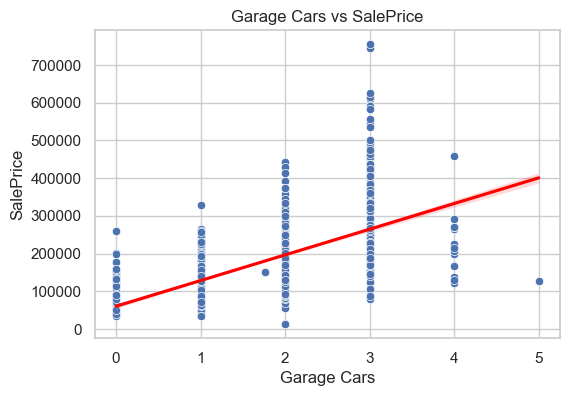

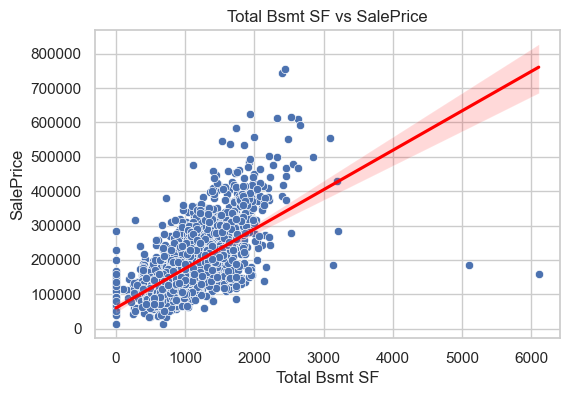

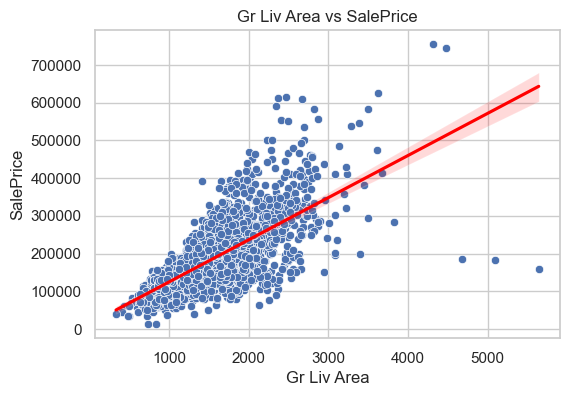

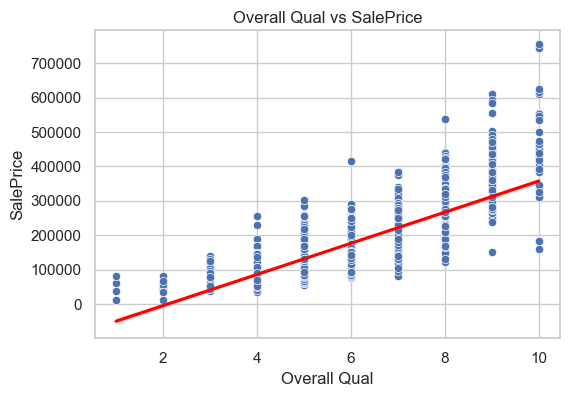

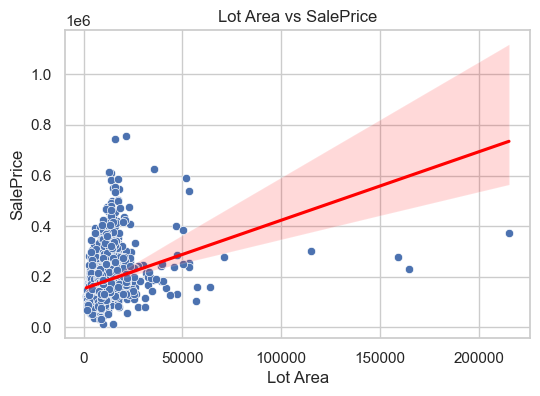

In [14]:
# -------------------------------
# Step 5: Scatter plots against SalePrice
# -------------------------------

features_to_plot = ['Garage Cars', 'Total Bsmt SF', 'Gr Liv Area', 'Overall Qual', 'Lot Area']

for feat in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=feat, y='SalePrice')
    
    # Add simple linear regression line (OLS)
    sns.regplot(data=df, x=feat, y='SalePrice', scatter=False, color='red')
    
    plt.title(f'{feat} vs SalePrice')
    plt.show()


In [15]:
# -------------------------------
# Step 6: Detect outliers (using z-score)
# -------------------------------
from scipy.stats import zscore

z_scores = df[numeric_cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)
outlier_indices = np.where(outliers.any(axis=1))[0]
print(f"\nNumber of potential outlier rows: {len(outlier_indices)}")
print(f"Indices of some outliers: {outlier_indices[:10]}")  # show first 10


Number of potential outlier rows: 878
Indices of some outliers: [ 0  2 11 14 15 16 17 18 44 46]


In [16]:
# ===============================
# Section 2: SGD Implementation
# ===============================

import numpy as np

class SGDRegressorCustom:
    """
    SGD Regressor with support for OLS, Ridge (L2) and Lasso (L1) using proximal step
    """
    def __init__(self, model_type='plain', lr=0.01, epochs=500, batch_size=16, lmbd=0.1, random_state=42):
        assert model_type in ['plain','ridge','lasso'], "model_type must be 'plain', 'ridge' or 'lasso'"
        self.model_type = model_type
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.lmbd = lmbd
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.train_loss_history = []
        self.val_loss_history = []

    def _compute_loss(self, X, y):
        y_pred = X.dot(self.weights) + self.bias
        mse = np.mean((y - y_pred)**2)
        return mse

    def _proximal_l1(self, w, lr_lmbd):
        # Soft-thresholding operator for Lasso
        return np.sign(w) * np.maximum(np.abs(w) - lr_lmbd, 0.0)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        np.random.seed(self.random_state)
        n_samples, n_features = X_train.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(1, self.epochs + 1):
            # Shuffle
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]

            # Mini-batch loop
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_train_shuffled[start:end]
                y_batch = y_train_shuffled[start:end]

                # Predictions
                y_pred = X_batch.dot(self.weights) + self.bias
                error = y_batch - y_pred

                # Gradient calculation
                grad_w = -2 * X_batch.T.dot(error) / len(X_batch)
                grad_b = -2 * np.mean(error)

                # Regularization
                if self.model_type == 'ridge':
                    grad_w += 2 * self.lmbd * self.weights  # L2 gradient

                # Update weights and bias
                self.weights -= self.lr * grad_w
                self.bias -= self.lr * grad_b

                # Lasso proximal step
                if self.model_type == 'lasso':
                    self.weights = self._proximal_l1(self.weights, self.lr * self.lmbd)

            # Compute epoch loss
            train_loss = self._compute_loss(X_train, y_train)
            self.train_loss_history.append(train_loss)
            
            if X_val is not None and y_val is not None:
                val_loss = self._compute_loss(X_val, y_val)
                self.val_loss_history.append(val_loss)
            
            # Optional: print progress
            if epoch % 50 == 0 or epoch == 1:
                print(f"Epoch {epoch}/{self.epochs} - Train Loss: {train_loss:.4f}" + \
                      (f" - Val Loss: {val_loss:.4f}" if X_val is not None else ""))

    def predict(self, X):
        return X.dot(self.weights) + self.bias


X_train shape: (2051, 38)
X_val shape: (439, 38)
X_test shape: (440, 38)
Epoch 1/500 - Train Loss: 0.2113 - Val Loss: 0.1837
Epoch 50/500 - Train Loss: 0.1772 - Val Loss: 0.1364
Epoch 100/500 - Train Loss: 0.2150 - Val Loss: 0.1557
Epoch 150/500 - Train Loss: 0.1820 - Val Loss: 0.1286
Epoch 200/500 - Train Loss: 0.1897 - Val Loss: 0.1520
Epoch 250/500 - Train Loss: 0.1776 - Val Loss: 0.1354
Epoch 300/500 - Train Loss: 0.3099 - Val Loss: 0.3197
Epoch 350/500 - Train Loss: 0.1901 - Val Loss: 0.1458
Epoch 400/500 - Train Loss: 0.1909 - Val Loss: 0.1637
Epoch 450/500 - Train Loss: 0.1755 - Val Loss: 0.1362
Epoch 500/500 - Train Loss: 0.1809 - Val Loss: 0.1396


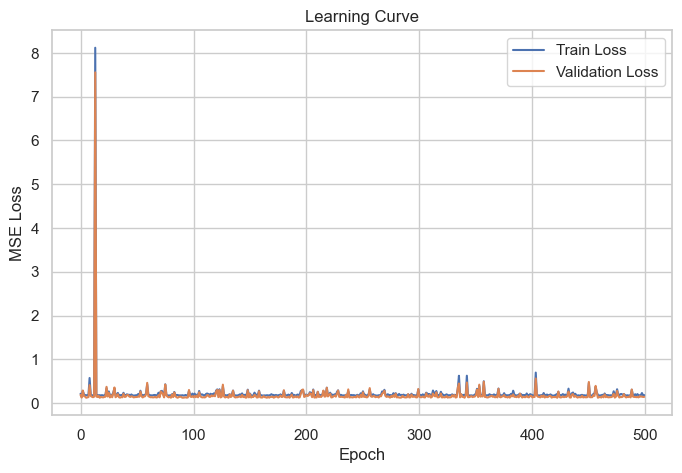

In [18]:
# ================================
# Step 1: Select Features & Target
# ================================
import numpy as np
from sklearn.model_selection import train_test_split

# Use only numeric columns for simplicity
numeric_cols = df_scaled.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('SalePrice')  # Target variable

X = df_scaled[numeric_cols].values
y = df_scaled['SalePrice'].values

# ================================
# Step 2: Split Data into Train / Val / Test
# ================================
# First, split into train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Split temp equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# ================================
# Step 3: Train SGD Model
# ================================
model = SGDRegressorCustom(
    model_type='ridge', 
    lr=0.01, 
    epochs=500, 
    batch_size=16, 
    lmbd=0.1
)

model.fit(X_train, y_train, X_val, y_val)

# ================================
# Step 4: Predictions on Test Set
# ================================
y_pred = model.predict(X_test)

# ================================
# Step 5: Plot Train / Validation Loss
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(model.train_loss_history, label='Train Loss')
plt.plot(model.val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()


In [19]:
# ================================
# SECTION 3: TRAINING ANALYSIS
# Effect of Standardization, Learning Curves, Over/Underfitting
# ================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# ------------------------
# Step 1: Define Hyperparameters
# ------------------------
lr = 0.01
batch_size = 16
lmbd = 0.1
epochs = 500
model_type = 'ridge'


In [20]:
# ------------------------
# Step 2: Train with Standardization
# ------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model_std = SGDRegressorCustom(
    model_type=model_type, lr=lr, batch_size=batch_size, epochs=epochs, lmbd=lmbd
)
model_std.fit(X_train_scaled, y_train, X_val_scaled, y_val)

Epoch 1/500 - Train Loss: 0.2037 - Val Loss: 0.1809
Epoch 50/500 - Train Loss: 0.1712 - Val Loss: 0.1351
Epoch 100/500 - Train Loss: 0.1891 - Val Loss: 0.1494
Epoch 150/500 - Train Loss: 0.1813 - Val Loss: 0.1284
Epoch 200/500 - Train Loss: 0.1782 - Val Loss: 0.1488
Epoch 250/500 - Train Loss: 0.1737 - Val Loss: 0.1346
Epoch 300/500 - Train Loss: 0.2999 - Val Loss: 0.3151
Epoch 350/500 - Train Loss: 0.1778 - Val Loss: 0.1417
Epoch 400/500 - Train Loss: 0.1790 - Val Loss: 0.1593
Epoch 450/500 - Train Loss: 0.1723 - Val Loss: 0.1355
Epoch 500/500 - Train Loss: 0.1795 - Val Loss: 0.1403


In [21]:
# ------------------------
# Step 3: Train without Standardization
# ------------------------
model_no_std = SGDRegressorCustom(
    model_type=model_type, lr=lr, batch_size=batch_size, epochs=epochs, lmbd=lmbd
)
model_no_std.fit(X_train, y_train, X_val, y_val)

Epoch 1/500 - Train Loss: 0.2113 - Val Loss: 0.1837
Epoch 50/500 - Train Loss: 0.1772 - Val Loss: 0.1364
Epoch 100/500 - Train Loss: 0.2150 - Val Loss: 0.1557
Epoch 150/500 - Train Loss: 0.1820 - Val Loss: 0.1286
Epoch 200/500 - Train Loss: 0.1897 - Val Loss: 0.1520
Epoch 250/500 - Train Loss: 0.1776 - Val Loss: 0.1354
Epoch 300/500 - Train Loss: 0.3099 - Val Loss: 0.3197
Epoch 350/500 - Train Loss: 0.1901 - Val Loss: 0.1458
Epoch 400/500 - Train Loss: 0.1909 - Val Loss: 0.1637
Epoch 450/500 - Train Loss: 0.1755 - Val Loss: 0.1362
Epoch 500/500 - Train Loss: 0.1809 - Val Loss: 0.1396


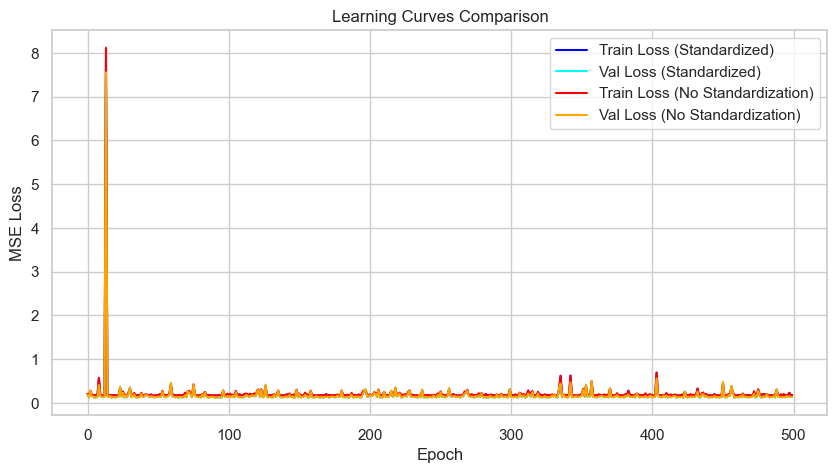

In [22]:
# ------------------------
# Step 4: Plot Learning Curves
# ------------------------
plt.figure(figsize=(10,5))

# Standardized
plt.plot(model_std.train_loss_history, label='Train Loss (Standardized)', color='blue')
plt.plot(model_std.val_loss_history, label='Val Loss (Standardized)', color='cyan')

# Non-standardized
plt.plot(model_no_std.train_loss_history, label='Train Loss (No Standardization)', color='red')
plt.plot(model_no_std.val_loss_history, label='Val Loss (No Standardization)', color='orange')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curves Comparison')
plt.legend()
plt.show()


In [23]:
# ------------------------
# Step 5: Compute Final Metrics on Test Set
# ------------------------
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, rmse, mae, r2

metrics_std = evaluate_model(model_std, X_test_scaled, y_test)
metrics_no_std = evaluate_model(model_no_std, X_test, y_test)

In [24]:
# ------------------------
# Step 6: Summarize in DataFrame
# ------------------------
summary = pd.DataFrame([
    {
        'Model': model_type,
        'Standardization': 'Yes',
        'LR': lr,
        'Batch': batch_size,
        'Lambda': lmbd,
        'Train RMSE': np.sqrt(model_std.train_loss_history[-1]),
        'Val RMSE': np.sqrt(model_std.val_loss_history[-1]),
        'Test RMSE': metrics_std[1],
        'Test MAE': metrics_std[2],
        'Test R2': metrics_std[3]
    },
    {
        'Model': model_type,
        'Standardization': 'No',
        'LR': lr,
        'Batch': batch_size,
        'Lambda': lmbd,
        'Train RMSE': np.sqrt(model_no_std.train_loss_history[-1]),
        'Val RMSE': np.sqrt(model_no_std.val_loss_history[-1]),
        'Test RMSE': metrics_no_std[1],
        'Test MAE': metrics_no_std[2],
        'Test R2': metrics_no_std[3]
    }
])

print(summary)

   Model Standardization    LR  Batch  Lambda  Train RMSE  Val RMSE  \
0  ridge             Yes  0.01     16     0.1    0.423647  0.374611   
1  ridge              No  0.01     16     0.1    0.425279  0.373574   

   Test RMSE  Test MAE   Test R2  
0   0.461206  0.291706  0.811738  
1   0.460128  0.289220  0.812618  


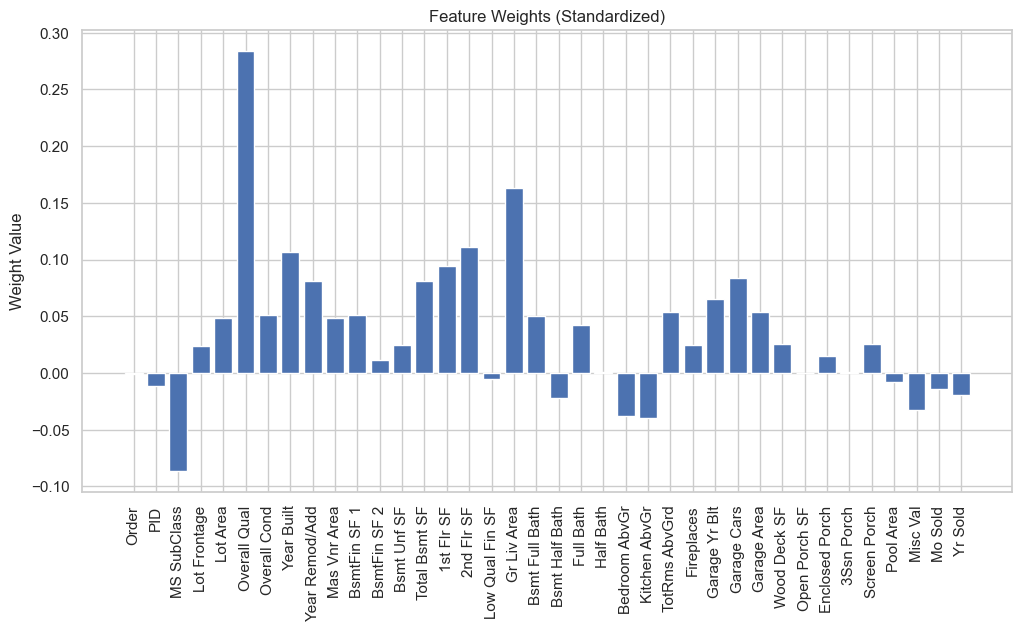

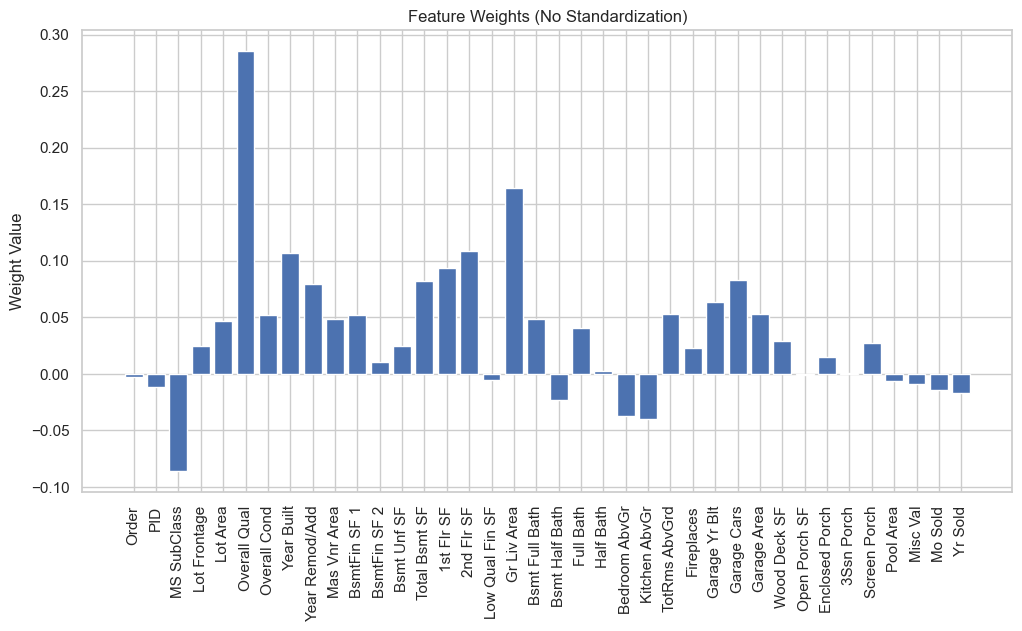

In [25]:
# ------------------------
# Step 7: Plot Coefficient Path
# ------------------------
def plot_coefficients_path(model, feature_names, title='Coefficient Path'):
    plt.figure(figsize=(12,6))
    weights_array = np.array(model.weights).reshape(1,-1)  # final epoch
    plt.bar(feature_names, weights_array.flatten())
    plt.xticks(rotation=90)
    plt.ylabel('Weight Value')
    plt.title(title)
    plt.show()

plot_coefficients_path(model_std, numeric_cols, title='Feature Weights (Standardized)')
plot_coefficients_path(model_no_std, numeric_cols, title='Feature Weights (No Standardization)')

In [26]:
# ================================
# SECTION 4: Learning Rate and Batch Size Analysis
# ================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------
# Step 1: Define Hyperparameters
# ------------------------
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [1, 16, 64]
epochs = 200
lmbd = 0.1
model_type = 'ridge'

# To store results
results = []

In [27]:
# ------------------------
# Step 2: Run experiments
# ------------------------
for batch_size in batch_sizes:
    for lr in learning_rates:
        print(f"Training with lr={lr}, batch_size={batch_size}")
        
        model = SGDRegressorCustom(
            model_type=model_type,
            lr=lr,
            batch_size=batch_size,
            epochs=epochs,
            lmbd=lmbd
        )
        
        # Fit the model (assume scaler applied already)
        model.fit(X_train_scaled, y_train, X_val_scaled, y_val)
        
        # Compute gradient statistics
        grad_norms = np.array(model.grad_norm_history)  # shape: [epochs]
        grad_mean = grad_norms.mean()
        grad_var = grad_norms.var()
        
        # Compute final test metrics
        y_pred_test = model.predict(X_test_scaled)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        
        # Save results
        results.append({
            'Learning Rate': lr,
            'Batch Size': batch_size,
            'Final Train Loss': model.train_loss_history[-1],
            'Final Val Loss': model.val_loss_history[-1],
            'Grad Norm Mean': grad_mean,
            'Grad Norm Var': grad_var,
            'Test RMSE': test_rmse,
            'Train Loss History': model.train_loss_history,
            'Val Loss History': model.val_loss_history
        })

# Convert to DataFrame for comparison
results_df = pd.DataFrame(results)
print(results_df[['Learning Rate', 'Batch Size', 'Final Train Loss', 
                  'Final Val Loss', 'Grad Norm Mean', 'Grad Norm Var', 'Test RMSE']])


Training with lr=0.001, batch_size=1
Epoch 1/200 - Train Loss: 0.2301 - Val Loss: 0.1988
Epoch 50/200 - Train Loss: 0.1769 - Val Loss: 0.1341
Epoch 100/200 - Train Loss: 0.2309 - Val Loss: 0.1613
Epoch 150/200 - Train Loss: 0.1731 - Val Loss: 0.1270
Epoch 200/200 - Train Loss: 0.1954 - Val Loss: 0.1536


AttributeError: 'SGDRegressorCustom' object has no attribute 'grad_norm_history'